# Atención y transformers

> El mecanismo de atención (consultas, claves y valores), la autoatención con varias cabezas, la codificación posicional y el bloque *transformer*, construidos desde cero en PyTorch. Entrenamos un pequeño modelo de lenguaje tipo GPT y lo comparamos con una LSTM, visualizamos qué miran sus cabezas y repasamos los errores típicos: entrenar solo con la última posición, olvidar la máscara causal o la de *padding*, y no compararse con una línea base.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · [Redes recurrentes](06-redes-recurrentes.ipynb) · **Relacionado:** [Embeddings de palabras](../06-nlp/04-embeddings-de-palabras.ipynb) · [Traducción automática](../06-nlp/09-traduccion-automatica.ipynb) · [Modelos de lenguaje preentrenados](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)

## 1. Idea clave

La **atención** permite que cada elemento de una secuencia consulte **directamente** a todos los demás y combine su información con pesos aprendidos, en lugar de recibirla paso a paso a través de un estado oculto como en una [red recurrente](06-redes-recurrentes.ipynb). El **transformer** es una arquitectura construida solo con atención, redes densas, conexiones residuales y normalización: no tiene recurrencia, así que procesa todas las posiciones **en paralelo** y relaciona elementos lejanos sin que la información se degrade por el camino.

Es la base de los modelos de lenguaje actuales (BERT, GPT), de la traducción automática y, cada vez más, de visión, audio y series temporales. Su coste crece con el **cuadrado** de la longitud de la secuencia y necesita muchos datos para brillar; con secuencias cortas y pocos datos, una LSTM puede rendir igual con menos esfuerzo.

## 2. Conceptos importantes

### 2.1. La atención como una búsqueda "suave"

Imagina un diccionario: una **consulta** (*query*) se compara con todas las **claves** (*keys*) y se devuelve el **valor** (*value*) de la que coincide. La atención hace lo mismo, pero de forma suave y diferenciable: compara la consulta con todas las claves, convierte las similitudes en pesos que suman 1 y devuelve la **media ponderada de los valores**. Nació en la traducción automática (Bahdanau et al., 2015), para que el decodificador "mirase" las palabras relevantes de la frase de origen en vez de depender de un único vector resumen.

### 2.2. Atención de producto escalar escalado

Con $n$ consultas $\mathbf{Q}\in\mathbb{R}^{n\times d_k}$, $m$ claves $\mathbf{K}\in\mathbb{R}^{m\times d_k}$ y sus valores $\mathbf{V}\in\mathbb{R}^{m\times d_v}$:

$$
\operatorname{Atención}(\mathbf{Q},\mathbf{K},\mathbf{V})=\operatorname{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}.
$$

La matriz $\mathbf{Q}\mathbf{K}^\top$ ($n\times m$) contiene las similitudes; el *softmax* se aplica **por filas**, de modo que cada consulta reparte un peso total de 1 entre las $m$ claves. Se divide entre $\sqrt{d_k}$ porque el producto escalar de dos vectores aleatorios de dimensión $d_k$ tiene varianza $d_k$: sin escalar, con $d_k$ grande las puntuaciones son enormes, el *softmax* se satura (casi todo el peso en una clave) y los gradientes se anulan (lo comprobamos en 3.1).

### 2.3. Autoatención y atención cruzada

En la **autoatención** (*self-attention*) consultas, claves y valores salen de la **misma** secuencia $\mathbf{X}\in\mathbb{R}^{n\times d}$ mediante tres proyecciones aprendidas: $\mathbf{Q}=\mathbf{X}\mathbf{W}_Q$, $\mathbf{K}=\mathbf{X}\mathbf{W}_K$, $\mathbf{V}=\mathbf{X}\mathbf{W}_V$. La nueva representación de cada elemento mezcla la de todos los demás según su relevancia ("banco" se representa distinto junto a "río" que junto a "dinero"). En la **atención cruzada** las consultas vienen de una secuencia (el decodificador) y las claves y valores de otra (el codificador).

### 2.4. Varias cabezas

Una sola atención solo puede expresar un tipo de relación a la vez. La **atención multicabeza** (*multi-head*) ejecuta $h$ atenciones en paralelo, cada una con sus propias proyecciones de dimensión $d_k=d/h$, concatena los resultados y los mezcla con una matriz $\mathbf{W}_O$:

$$
\operatorname{MultiCabeza}(\mathbf{X})=[\,\text{cabeza}_1,\dots,\text{cabeza}_h\,]\,\mathbf{W}_O,\qquad \text{cabeza}_i=\operatorname{Atención}(\mathbf{X}\mathbf{W}_Q^{(i)},\mathbf{X}\mathbf{W}_K^{(i)},\mathbf{X}\mathbf{W}_V^{(i)}).
$$

El coste es el mismo que una cabeza de dimensión $d$; cada cabeza puede especializarse (por ejemplo, en mirar la palabra anterior, 3.5).

### 2.5. Máscaras

Antes del *softmax* se pone $-\infty$ en las posiciones que una consulta **no** debe ver, y su peso queda en 0:

- **Máscara causal**: en un modelo que genera texto, la posición $t$ solo puede mirar las posiciones $\le t$; si viera las siguientes, conocería la respuesta (demo en 4.2).
- **Máscara de *padding***: cuando se rellenan secuencias cortas con un token de relleno para formar un lote, nadie debe atender a esas posiciones (demo en 4.2).

### 2.6. Codificación posicional

La atención trata la entrada como un **conjunto**: si se permutan las palabras, las salidas se permutan igual, y "el perro muerde al hombre" no se distinguiría de "el hombre muerde al perro". Por eso se **suma** a cada embedding un vector que depende de su posición $p$. El original usa senos y cosenos de frecuencias distintas ($i$ indexa las dimensiones):

$$
\mathrm{PE}_{(p,\,2i)}=\sin\!\left(\frac{p}{10000^{2i/d}}\right),\qquad \mathrm{PE}_{(p,\,2i+1)}=\cos\!\left(\frac{p}{10000^{2i/d}}\right).
$$

También se pueden aprender los vectores de posición (BERT, GPT-2) o codificar posiciones relativas (RoPE, en muchos modelos recientes).

### 2.7. El bloque transformer y las tres familias

Un bloque combina autoatención multicabeza y una red densa de dos capas aplicada a cada posición (*feed-forward*, normalmente con $4d$ neuronas ocultas), cada una con **conexión residual** y **normalización de capa** (*LayerNorm*). En la variante *pre-norm*, la más usada hoy:

$$
\mathbf{X}\leftarrow\mathbf{X}+\operatorname{MultiCabeza}(\operatorname{LN}(\mathbf{X})),\qquad \mathbf{X}\leftarrow\mathbf{X}+\operatorname{FFN}(\operatorname{LN}(\mathbf{X})).
$$

Se apilan $N$ bloques. Según cómo se combinen hay tres familias:

| Familia | Atención | Ejemplos | Uso típico |
|---|---|---|---|
| **Solo codificador** | Bidireccional (todas las posiciones) | BERT | Clasificar, extraer, embeddings ([modelos preentrenados](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)) |
| **Solo decodificador** | Causal | GPT | Generar texto (lo que construimos aquí) |
| **Codificador-decodificador** | Bidireccional + causal + cruzada | Transformer original, T5 | Traducir, resumir ([traducción](../06-nlp/09-traduccion-automatica.ipynb)) |

### 2.8. Modelo de lenguaje y perplejidad

Un **modelo de lenguaje** causal predice el siguiente token dado el anterior contexto. Con la máscara causal, una sola pasada por una secuencia de $n$ tokens da **$n$ predicciones a la vez** (la de cada posición), y la pérdida es la entropía cruzada media sobre todas ellas. Se resume con la **perplejidad**:

$$
\mathrm{PPL}=\exp\!\left(-\frac{1}{n}\sum_{t=1}^{n}\log p_\theta(w_t\mid w_{<t})\right),
$$

que se interpreta como el número efectivo de palabras entre las que duda el modelo: un modelo que reparte la probabilidad uniformemente entre $V$ palabras tiene $\mathrm{PPL}=V$.

### 2.9. Coste

La autoatención calcula una matriz $n\times n$: memoria y tiempo crecen como $O(n^2 d)$, lo que limita la longitud del contexto. Una RNN cuesta $O(n d^2)$ pero es **secuencial**: no se puede paralelizar a lo largo de la secuencia. En entrenamiento el transformer aprovecha mucho mejor la GPU.

## 3. Código

Usamos **WikiText-2** (artículos de Wikipedia en inglés: unos 2 millones de palabras de entrenamiento, 217 000 de validación y 245 000 de test) desde Hugging Face, en su versión *raw* (texto original). Tokenizamos por palabras y signos de puntuación, en minúsculas, con un vocabulario de 10 000 tokens: las 9 998 palabras más frecuentes del entrenamiento, `<unk>` para todas las demás y `<pad>` para el relleno (4.2). La tokenización por subpalabras de los modelos reales se ve en [modelos de lenguaje preentrenados](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb).

In [1]:
import contextlib
import io
import math
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False
hf_logging.set_verbosity_error()                          # sin avisos de la descarga

### 3.1. La atención desde cero

Una función de 6 líneas que implementa la fórmula de 2.2 con máscara opcional. La comparamos con la de PyTorch (`F.scaled_dot_product_attention`) sobre 5 tokens de dimensión 8 con máscara causal, y comprobamos el efecto de dividir entre $\sqrt{d_k}$ con vectores aleatorios de distinta dimensión.

In [2]:
def atencion(Q, K, V, mascara=None):
    """Q: (..., n, d_k), K: (..., m, d_k), V: (..., m, d_v); mascara: True donde NO se puede mirar."""
    puntuaciones = Q @ K.transpose(-2, -1) / Q.shape[-1] ** 0.5
    if mascara is not None:
        puntuaciones = puntuaciones.masked_fill(mascara, float("-inf"))
    pesos = puntuaciones.softmax(dim=-1)                  # cada fila suma 1
    return pesos @ V, pesos

g = torch.Generator().manual_seed(42)
Q, K, V = (torch.randn(5, 8, generator=g) for _ in range(3))
causal = torch.triu(torch.ones(5, 5, dtype=torch.bool), diagonal=1)   # True por encima de la diagonal
salida, pesos = atencion(Q, K, V, causal)
print("¿Igual que F.scaled_dot_product_attention?", torch.allclose(salida, F.scaled_dot_product_attention(Q, K, V, is_causal=True), atol=1e-6))
print("Pesos con máscara causal (fila = consulta, columna = clave):")
print(pd.DataFrame(pesos.numpy()).round(2).to_string())

print("\nPeso máximo medio de cada fila del softmax, con vectores aleatorios:")
for d_k in [8, 64, 512]:
    q, k = torch.randn(1000, d_k, generator=g), torch.randn(50, d_k, generator=g)
    sin_escalar = (q @ k.T).softmax(-1).max(-1).values.mean()
    escalado = (q @ k.T / d_k ** 0.5).softmax(-1).max(-1).values.mean()
    print(f"  d_k = {d_k:>3}: sin escalar {sin_escalar:.2f} | dividiendo entre √d_k {escalado:.2f}   (50 claves; uniforme = 0.02)")

¿Igual que F.scaled_dot_product_attention? True
Pesos con máscara causal (fila = consulta, columna = clave):
      0     1     2     3     4
0  1.00  0.00  0.00  0.00  0.00
1  0.20  0.80  0.00  0.00  0.00
2  0.19  0.11  0.70  0.00  0.00
3  0.33  0.24  0.12  0.32  0.00
4  0.06  0.57  0.03  0.23  0.11

Peso máximo medio de cada fila del softmax, con vectores aleatorios:
  d_k =   8: sin escalar 0.43 | dividiendo entre √d_k 0.12   (50 claves; uniforme = 0.02)
  d_k =  64: sin escalar 0.79 | dividiendo entre √d_k 0.12   (50 claves; uniforme = 0.02)
  d_k = 512: sin escalar 0.94 | dividiendo entre √d_k 0.12   (50 claves; uniforme = 0.02)


Nuestra función da exactamente lo mismo que la de PyTorch. Con la máscara causal, la primera consulta solo puede mirarse a sí misma (peso 1) y cada fila reparte su peso entre las posiciones anteriores y la propia, con ceros por encima de la diagonal.

Sin dividir entre $\sqrt{d_k}$, el *softmax* se concentra cada vez más al crecer la dimensión: con $d_k=512$ el peso máximo medio es 0,94, casi toda la atención en una sola clave (un *softmax* saturado, con gradientes casi nulos). Escalando, el peso máximo se queda en 0,12 sea cual sea $d_k$.

### 3.2. Datos y líneas base

In [3]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    wikitext = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", cache_dir="data")

def tokenizar(textos):
    return re.findall(r"\w+|[^\w\s]", " ".join(textos).lower())

tokens = {parte: tokenizar(wikitext[parte]["text"]) for parte in ["train", "validation", "test"]}
frecuencias = Counter(tokens["train"])
vocabulario = ["<pad>", "<unk>"] + [w for w, _ in frecuencias.most_common(10_000 - 2)]
indice = {w: i for i, w in enumerate(vocabulario)}
V_TAM, PAD, UNK = len(vocabulario), indice["<pad>"], indice["<unk>"]
ids = {parte: torch.tensor([indice.get(w, UNK) for w in t]) for parte, t in tokens.items()}

print(f"Palabras distintas en entrenamiento: {len(frecuencias):,} -> vocabulario de {V_TAM:,}")
for parte, t in ids.items():
    print(f"  {parte:>10}: {len(t):>9,} tokens, {(t == UNK).float().mean():.1%} <unk>")
print("Más frecuentes:", [w for w, _ in frecuencias.most_common(8)])

Palabras distintas en entrenamiento: 65,989 -> vocabulario de 10,000
       train: 2,122,137 tokens, 7.7% <unk>
  validation:   221,611 tokens, 9.3% <unk>
        test:   249,691 tokens, 10.2% <unk>
Más frecuentes: ['the', ',', '.', 'of', 'and', '@', 'in', 'to']


Dos líneas base que no miran el contexto: predecir siempre el token más frecuente, y un modelo de **unigramas** (cada palabra con su frecuencia de entrenamiento, sin tener en cuenta las anteriores), cuya perplejidad es la referencia que cualquier modelo de lenguaje debe mejorar.

In [4]:
conteo = torch.bincount(ids["train"], minlength=V_TAM).float() + 1     # +1: suavizado de Laplace
log_p_unigrama = (conteo / conteo.sum()).log()
mas_frecuente = conteo.argmax()
lineas_base = {"Siempre el más frecuente": {"acierto": (ids["validation"] == mas_frecuente).float().mean().item(), "perplejidad": float("nan")},
               "Unigramas": {"acierto": (ids["validation"] == mas_frecuente).float().mean().item(),
                             "perplejidad": math.exp(-log_p_unigrama[ids["validation"]].mean().item())}}
print(f"Token más frecuente: '{vocabulario[mas_frecuente]}'")
pd.DataFrame(lineas_base).T.round(3)

Token más frecuente: '<unk>'


,acierto,perplejidad
Siempre el más frecuente,0.093,NaN
Unigramas,0.093,472.895


El texto de entrenamiento tiene 65 989 palabras distintas, pero las 9 998 más frecuentes cubren el 92,3 % de los tokens (el 7,7 % pasa a `<unk>`; el 9,3 % en validación). Al agrupar todas las palabras raras, `<unk>` se convierte en el token más frecuente, por delante de *the*, la coma y el punto, y predecirlo siempre acierta el **9,3 %** de las veces. El modelo de unigramas tiene una perplejidad de **473**: sin mirar el contexto, duda en promedio entre unas 470 palabras. (Los `@` vienen de cómo WikiText escribe los números, por ejemplo `1 @,@ 000`.)

### 3.3. Dos modelos de lenguaje: LSTM y transformer

Cortamos cada parte en secuencias de 64 tokens; el objetivo de cada posición es el token siguiente (la entrada desplazada una posición). El transformer es un decodificador tipo GPT construido con la función `atencion` de 3.1: embedding + codificación posicional sinusoidal, 2 bloques *pre-norm* con 4 cabezas y $d=128$, y una capa lineal hasta el vocabulario. La LSTM tiene 2 capas de 128 unidades. Ambos predicen **todas las posiciones** a la vez.

In [5]:
CONTEXTO = 64

def secuencias(t, n=CONTEXTO):
    bloques = t[: (len(t) - 1) // n * n + 1]
    X = bloques[:-1].view(-1, n)
    Y = bloques[1:].view(-1, n)                           # el objetivo es el token siguiente
    return X, Y

X_tr, Y_tr = secuencias(ids["train"])
X_va, Y_va = secuencias(ids["validation"])
print("Secuencias de entrenamiento:", tuple(X_tr.shape), "| validación:", tuple(X_va.shape))
print("Entrada :", " ".join(vocabulario[i] for i in X_tr[3, :12]))
print("Objetivo:", " ".join(vocabulario[i] for i in Y_tr[3, :12]))

Secuencias de entrenamiento: (33158, 64) | validación: (3462, 64)
Entrada : <unk> <unk> both returned from previous <unk> , along with valkyria chronicles
Objetivo: <unk> both returned from previous <unk> , along with valkyria chronicles ii


In [6]:
def codificacion_posicional(n, d):
    p = torch.arange(n).unsqueeze(1)
    frecuencias_pe = 10000 ** (-torch.arange(0, d, 2) / d)
    pe = torch.zeros(n, d)
    pe[:, 0::2], pe[:, 1::2] = torch.sin(p * frecuencias_pe), torch.cos(p * frecuencias_pe)
    return pe

class MultiCabeza(nn.Module):
    def __init__(self, d, cabezas):
        super().__init__()
        assert d % cabezas == 0, "d debe ser divisible entre el número de cabezas"
        self.cabezas = cabezas
        self.qkv = nn.Linear(d, 3 * d)                    # W_Q, W_K y W_V de todas las cabezas a la vez
        self.W_O = nn.Linear(d, d)

    def forward(self, x, mascara):
        N, n, d = x.shape
        q, k, v = self.qkv(x).view(N, n, 3, self.cabezas, d // self.cabezas).permute(2, 0, 3, 1, 4)   # 3 x (N, h, n, d/h)
        salida, pesos = atencion(q, k, v, mascara)
        return self.W_O(salida.transpose(1, 2).reshape(N, n, d)), pesos

class Bloque(nn.Module):
    def __init__(self, d, cabezas, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.atencion = MultiCabeza(d, cabezas)
        self.ffn = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mascara):
        a, pesos = self.atencion(self.ln1(x), mascara)
        x = x + self.dropout(a)                           # conexión residual
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x, pesos

class TransformerLM(nn.Module):
    def __init__(self, V, d=128, cabezas=4, capas=2, contexto=CONTEXTO, causal=True):
        super().__init__()
        self.embedding = nn.Embedding(V, d)
        self.register_buffer("pe", codificacion_posicional(contexto, d))
        self.bloques = nn.ModuleList([Bloque(d, cabezas) for _ in range(capas)])
        self.ln, self.salida = nn.LayerNorm(d), nn.Linear(d, V)
        self.causal = causal

    def forward(self, x, mascara_extra=None, posiciones=None, devolver_pesos=False):
        n = x.shape[1]
        h = self.embedding(x) + (self.pe[:n] if posiciones is None else self.pe[posiciones])
        mascara = torch.triu(torch.ones(n, n, dtype=torch.bool, device=x.device), 1) if self.causal else None
        if mascara_extra is not None:
            mascara = mascara_extra if mascara is None else mascara | mascara_extra
        pesos = []
        for bloque in self.bloques:
            h, p = bloque(h, mascara)
            pesos.append(p)
        logits = self.salida(self.ln(h))                  # (N, n, V): una predicción por posición
        return (logits, pesos) if devolver_pesos else logits

class LSTMLM(nn.Module):
    def __init__(self, V, d=128, capas=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(V, d)
        self.lstm = nn.LSTM(d, d, capas, batch_first=True, dropout=dropout)
        self.salida = nn.Linear(d, V)

    def forward(self, x):
        h, _ = self.lstm(self.embedding(x))
        return self.salida(h)

def resumen_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    vocab = modelo.embedding.weight.numel() + sum(p.numel() for p in modelo.salida.parameters())
    return f"{total:,} parámetros ({vocab / total:.0%} en el embedding y la capa de salida)"

El bucle de entrenamiento admite dos modos: pérdida en **todas** las posiciones (lo correcto) o solo en la **última** (lo usaremos en 3.6). Evaluamos en validación la pérdida media en todas las posiciones (perplejidad), el acierto y la pérdida de la última posición, que es comparable entre ambos modos.

In [7]:
def evaluar(modelo, X, Y):
    modelo.eval()
    perdida, ultima, aciertos = 0.0, 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), 256):
            xb, yb = X[i:i + 256].to(device), Y[i:i + 256].to(device)
            logits = modelo(xb)
            perdida += F.cross_entropy(logits.reshape(-1, V_TAM), yb.reshape(-1), reduction="sum").item()
            ultima += F.cross_entropy(logits[:, -1], yb[:, -1], reduction="sum").item()
            aciertos += (logits.argmax(-1) == yb).sum().item()
    return {"perplejidad": math.exp(perdida / Y.numel()), "acierto": aciertos / Y.numel(), "pérdida última posición": ultima / len(Y)}

def entrenar(modelo, epocas=6, lr=1e-3, solo_ultima=False, semilla=0):
    modelo.to(device)
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=0.01)
    cargador = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(semilla))
    historia, inicio = [], time.time()
    for epoca in range(epocas):
        modelo.train()
        for xb, yb in cargador:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo(xb)
            if solo_ultima:
                perdida = F.cross_entropy(logits[:, -1], yb[:, -1])
            else:
                perdida = F.cross_entropy(logits.reshape(-1, V_TAM), yb.reshape(-1))
            opt.zero_grad()
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            opt.step()
        historia.append({"época": epoca + 1, **evaluar(modelo, X_va, Y_va)})
    modelo.segundos = time.time() - inicio
    return modelo, pd.DataFrame(historia)

torch.manual_seed(0)
lstm, hist_lstm = entrenar(LSTMLM(V_TAM))
torch.manual_seed(0)
transformer, hist_transformer = entrenar(TransformerLM(V_TAM))
for nombre, m in [("LSTM", lstm), ("Transformer", transformer)]:
    print(f"{nombre:>11}: {resumen_parametros(m)}, {m.segundos:.0f} s")

       LSTM: 2,834,192 parámetros (91% en el embedding y la capa de salida), 92 s
Transformer: 2,966,800 parámetros (87% en el embedding y la capa de salida), 114 s


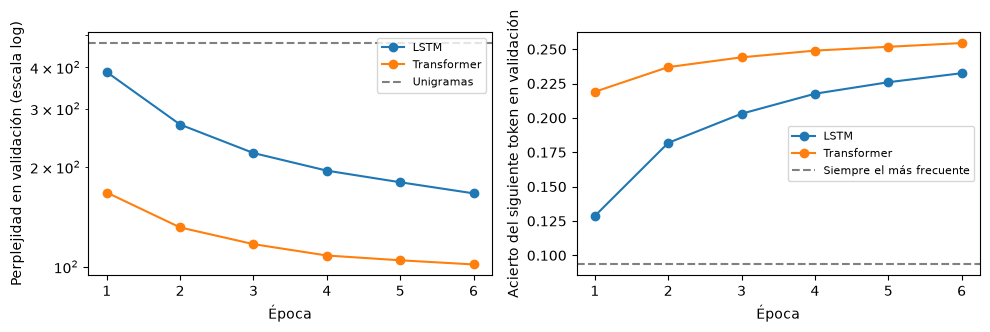

,perplejidad,acierto,pérdida última posición
LSTM,166.456,0.233,5.110
Transformer,101.586,0.254,4.582


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for nombre, h in [("LSTM", hist_lstm), ("Transformer", hist_transformer)]:
    axes[0].plot(h["época"], h["perplejidad"], marker="o", label=nombre)
    axes[1].plot(h["época"], h["acierto"], marker="o", label=nombre)
axes[0].axhline(lineas_base["Unigramas"]["perplejidad"], color="gray", ls="--", label="Unigramas")
axes[1].axhline(lineas_base["Siempre el más frecuente"]["acierto"], color="gray", ls="--", label="Siempre el más frecuente")
axes[0].set_yscale("log"); axes[0].set_ylabel("Perplejidad en validación (escala log)")
axes[1].set_ylabel("Acierto del siguiente token en validación")
for ax in axes:
    ax.set_xlabel("Época"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame({"LSTM": hist_lstm.iloc[-1], "Transformer": hist_transformer.iloc[-1]}).T.drop(columns="época").round(3)

Con un número de parámetros parecido (2,8 y 3,0 millones) y la misma receta de entrenamiento, el transformer llega a una perplejidad de **102** frente a 166 de la LSTM, y acierta el siguiente token el 25,4 % de las veces frente al 23,3 %. Los dos mejoran claramente las líneas base (473 de perplejidad y 9,3 % de acierto), y la curva del transformer va por debajo de la de la LSTM en todas las épocas. Es un solo entrenamiento por modelo: la diferencia es grande, pero no hemos medido la variación entre semillas.

Entre el 87 % y el 91 % de los parámetros están en el embedding y la capa de salida ($2\times10\,000\times128$, más los sesgos): con modelos pequeños, el tamaño del vocabulario manda.

### 3.4. Generar texto

Para generar, se da un comienzo, se toma la distribución del siguiente token en la última posición, se muestrea (con una **temperatura** $\tau$ que divide los logits: $\tau<1$ la hace más conservadora) y se añade al contexto, repitiendo el proceso. Excluimos `<unk>` del muestreo.

In [9]:
def generar(modelo, comienzo, n=25, temperatura=0.8, semilla=0):
    modelo.eval()
    g = torch.Generator(device=device).manual_seed(semilla)
    contexto = [indice.get(w, UNK) for w in tokenizar([comienzo])]
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor([contexto[-CONTEXTO:]], device=device)
            logits = modelo(x)[0, -1] / temperatura
            logits[[UNK, PAD]] = float("-inf")
            contexto.append(torch.multinomial(logits.softmax(-1), 1, generator=g).item())
    return " ".join(vocabulario[i] for i in contexto)

for nombre, m in [("LSTM", lstm), ("Transformer", transformer)]:
    print(f"{nombre}:\n  {generar(m, 'the city is located in')}\n")

LSTM:
  the city is located in jutland on april 29 . the song is the ultimate few force , and the " sinking the next louisiana , which that the "



Transformer:
  the city is located in the city , oldham . the song is the island of the province of the town , the tom cruise , which is the same



Ninguno de los dos escribe frases con sentido (son modelos de 3 millones de parámetros entrenados un par de minutos con 2 millones de palabras), pero los dos han aprendido la estructura local del inglés de Wikipedia: artículos delante de sustantivos, comas y puntos en su sitio y expresiones frecuentes como *located in*, *the province of* o *which is the same*. Ninguno mantiene el tema más allá de unas pocas palabras.

### 3.5. ¿Qué miran las cabezas?

Pasamos una frase de validación por el transformer y dibujamos los pesos de atención de las 4 cabezas de cada bloque (fila = palabra que consulta, columna = palabra consultada). Por la máscara causal, todo lo que está por encima de la diagonal vale 0. Además, medimos en todo el conjunto de validación qué parte del peso pone cada cabeza en la **propia palabra**, en la **anterior** y en la **primera** de la secuencia.

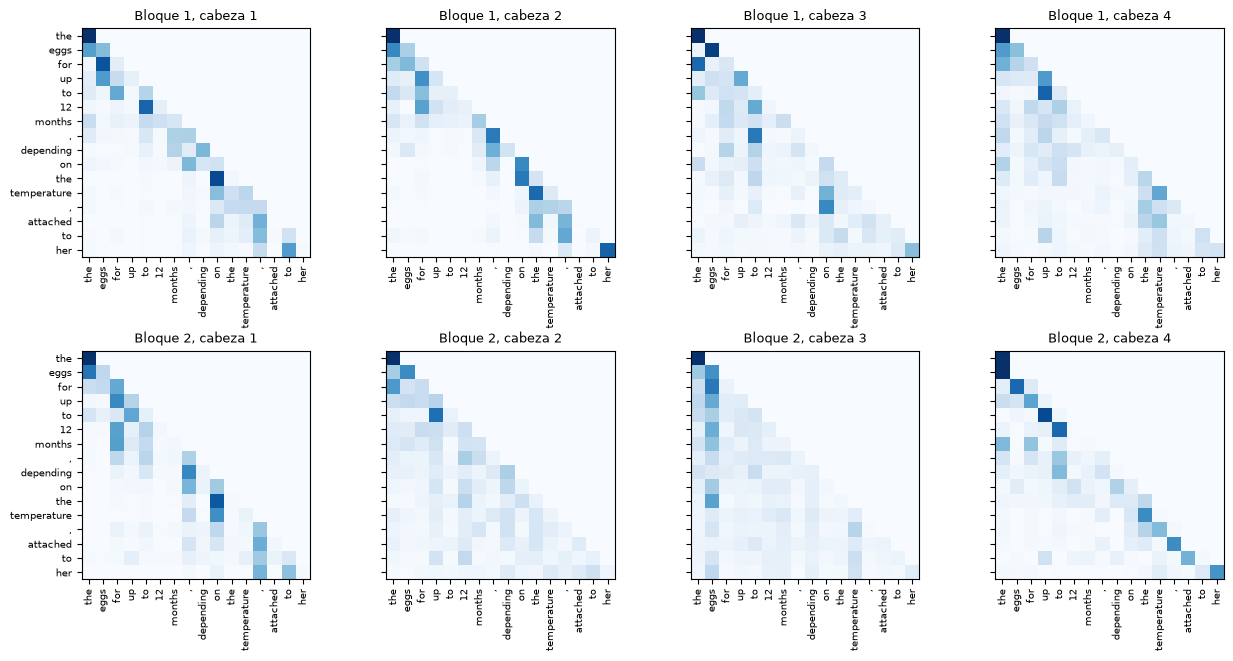

,propia palabra,palabra anterior,primera palabra
"bloque 1, cabeza 1",0.23,0.29,0.02
"bloque 1, cabeza 2",0.28,0.34,0.02
"bloque 1, cabeza 3",0.12,0.15,0.03
"bloque 1, cabeza 4",0.16,0.12,0.03
"bloque 2, cabeza 1",0.13,0.23,0.03
"bloque 2, cabeza 2",0.10,0.16,0.03
"bloque 2, cabeza 3",0.05,0.07,0.06
"bloque 2, cabeza 4",0.08,0.27,0.03


In [10]:
frase = X_va[10, :16].unsqueeze(0).to(device)
palabras = [vocabulario[i] for i in frase[0]]
transformer.eval()
with torch.no_grad():
    _, pesos_frase = transformer(frase, devolver_pesos=True)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
for capa in range(2):
    for cabeza in range(4):
        ax = axes[capa, cabeza]
        ax.imshow(pesos_frase[capa][0, cabeza].cpu(), cmap="Blues", vmin=0, vmax=1)
        ax.set_title(f"Bloque {capa + 1}, cabeza {cabeza + 1}", fontsize=9)
        ax.set_xticks(range(16)); ax.set_xticklabels(palabras, rotation=90, fontsize=7)
        ax.set_yticks(range(16)); ax.set_yticklabels(palabras if cabeza == 0 else [], fontsize=7)
plt.tight_layout()
plt.show()

with torch.no_grad():
    _, pesos_val = transformer(X_va[:512].to(device), devolver_pesos=True)
filas = {}
for capa, p in enumerate(pesos_val):                       # p: (N, cabezas, n, n)
    for cabeza in range(p.shape[1]):
        m = p[:, cabeza, 1:, :]                            # desde la 2.ª posición (la 1.ª solo puede mirarse a sí misma)
        filas[f"bloque {capa + 1}, cabeza {cabeza + 1}"] = {
            "propia palabra": m.diagonal(offset=1, dim1=-2, dim2=-1).mean().item(),
            "palabra anterior": m.diagonal(offset=0, dim1=-2, dim2=-1).mean().item(),
            "primera palabra": m[..., 0].mean().item()}
pd.DataFrame(filas).T.round(2)

Las cabezas se reparten el trabajo. Las cabezas 1 y 2 del primer bloque ponen entre un 29 % y un 34 % de su peso en la **palabra anterior** (y entre un 23 % y un 28 % en la propia): es la diagonal que se ve en sus mapas, una especialización típica, porque la palabra anterior es la mejor pista para la siguiente. Como referencia, si cada posición repartiera su peso por igual entre las que puede ver, a cada una le tocaría de media un 6 %. Otras cabezas reparten la atención más ampliamente, como la 3 del segundo bloque (menos del 7 % en cada una de las tres categorías), que en la frase de ejemplo mira sobre todo a *eggs*, la palabra con más contenido. Ninguna se concentra en la primera palabra (entre un 2 % y un 6 %).

### 3.6. Aprender de todas las posiciones o solo de la última

Una forma habitual (y errónea) de entrenar un modelo de lenguaje es usar cada secuencia para predecir **solo el token que la sigue**, como un clasificador. Entrenamos el mismo transformer, con las mismas épocas, calculando la pérdida solo en la última posición, y comparamos la pérdida en la última posición de validación, que mide lo mismo en los dos casos.

In [11]:
torch.manual_seed(0)
transformer_ultima, hist_ultima = entrenar(TransformerLM(V_TAM), solo_ultima=True)
comparacion = pd.DataFrame({"Todas las posiciones": hist_transformer.iloc[-1], "Solo la última": hist_ultima.iloc[-1]}).T
comparacion["perplejidad última posición"] = np.exp(comparacion["pérdida última posición"])
comparacion[["pérdida última posición", "perplejidad última posición"]].round(2)

,pérdida última posición,perplejidad última posición
Todas las posiciones,4.58,97.74
Solo la última,6.53,682.28


Con los mismos datos y épocas, el modelo entrenado solo con la última posición tiene una perplejidad de **682** en esa posición, peor incluso que el modelo de unigramas (473), que ni siquiera mira el contexto; el entrenado con todas las posiciones se queda en **98**. Cada secuencia de 64 tokens le aporta un ejemplo en lugar de 64: recibe 64 veces menos señal por época. Por eso los modelos de lenguaje se entrenan con máscara causal y pérdida en todas las posiciones.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| $d$ (`d_model`) | Tamaño de las representaciones | 128–1024; múltiplo del número de cabezas |
| Número de cabezas $h$ | Relaciones distintas en paralelo | $d/h$ entre 32 y 128 (4–16 cabezas) |
| Número de bloques $N$ | Profundidad | 2–6 en modelos pequeños; más bloques necesitan más datos |
| Neuronas de la FFN | Capacidad por posición | $4d$ |
| Longitud del contexto | Cuánto pasado se ve | Coste $O(n^2)$ en memoria; ajústala a la tarea |
| Tamaño del vocabulario $V$ | Parámetros del embedding y de la salida ($2Vd$) | Subpalabras (BPE, WordPiece) con 30 000–50 000 tokens; por palabras, recorta a las más frecuentes |
| Tasa de aprendizaje | Estabilidad | $10^{-4}$–$10^{-3}$ con AdamW; en modelos grandes, calentamiento (*warm-up*) y decaimiento |
| *Dropout*, *weight decay* | Regularización | 0,1 y 0,01 son buenos puntos de partida |
| Temperatura (al generar) | Diversidad del texto | 0,7–1; más baja = más repetitivo, más alta = más incoherente |

### 4.2. Errores comunes

- **No compararse con una línea base.** Un acierto del 8–9 % puede parecer un modelo que "aprende algo", pero es lo que se obtiene prediciendo siempre el token más frecuente (3.2: 9,3 %). Compara también la perplejidad con la de unigramas.
- **Un vocabulario enorme con un modelo pequeño.** Con 65 000 palabras y $d=50$, más del 99 % de los parámetros están en el embedding y la capa de salida (aquí, con 10 000, el 87–91 %, 3.3), y casi todas las palabras aparecen tan pocas veces que no se aprenden. Recorta el vocabulario o usa subpalabras.
- **Calcular la pérdida solo en la última posición.** Desperdicia 63 de cada 64 predicciones y el modelo aprende mucho más despacio (3.6).
- **Olvidar la máscara causal.** El modelo ve el token que debe predecir y la pérdida de entrenamiento cae casi a cero, pero al generar (sin futuro que copiar) no sirve (demo siguiente).
- **Rellenar (*padding*) sin máscara de *padding*.** Si una frase corta se completa por la izquierda con tokens de relleno y no se enmascaran, el modelo reparte atención entre ellos y su predicción cambia (demo siguiente). Y si al dibujar la atención se recorta la matriz a las posiciones reales y se renormaliza cada fila, el problema desaparece del gráfico aunque siga en el modelo.
- **Olvidar la codificación posicional.** Sin ella, la atención no distingue el orden de las palabras (2.6).
- **Parar demasiado pronto.** Con una tasa de aprendizaje baja ($10^{-4}$), pocas épocas y una paciencia de 1–2 épocas, la parada temprana corta el entrenamiento antes de que el modelo pase de la línea base.
- **Leer la atención como una explicación.** Los pesos indican de dónde se mezcla información en una capa, no por qué el modelo decide algo; tras varias capas, cada posición ya contiene información de las demás.

#### Demo: sin máscara causal

In [12]:
torch.manual_seed(0)
tramposo, hist_tramposo = entrenar(TransformerLM(V_TAM, causal=False), epocas=2)
print(f"Sin máscara causal, tras 2 épocas: perplejidad en validación {hist_tramposo['perplejidad'].iloc[-1]:.1f}")
tramposo.causal = True                                    # al generar no hay futuro que mirar
print(f"El mismo modelo usado con máscara causal: perplejidad {evaluar(tramposo, X_va, Y_va)['perplejidad']:,.0f}")

Sin máscara causal, tras 2 épocas: perplejidad en validación 1.9


El mismo modelo usado con máscara causal: perplejidad 251,661


Sin máscara, la posición $t$ ve el token $t+1$, que es justo lo que debe predecir: en dos épocas el modelo aprende a copiarlo y llega a una perplejidad de 1,9 en validación, un valor imposible para un modelo de lenguaje real. En cuanto se le quita el futuro (como ocurre al generar texto), la perplejidad sube a más de 250 000, peor que elegir al azar entre las 10 000 palabras del vocabulario (perplejidad 10 000): no ha aprendido a usar el pasado. Una pérdida sospechosamente baja es la pista.

#### Demo: *padding* sin máscara

Tomamos 5 palabras y las rellenamos por la izquierda con `<pad>` hasta 64 posiciones, como se haría para meterlas en un lote. Medimos qué parte de la atención de las palabras reales (bloque 1, media de cabezas) va a parar al relleno y cuánto cambia la distribución de la siguiente palabra respecto a pasar la frase sola (distancia de variación total: 0 = idénticas, 1 = sin nada en común). Probamos sin máscara, con máscara de *padding* y con máscara más **posiciones corregidas** (que la primera palabra real reciba la posición 0, como en la frase sola).

In [13]:
corta = torch.tensor([[indice[w] for w in tokenizar(["the first season of the"])]], device=device)
rellena = torch.cat([torch.full((1, CONTEXTO - corta.shape[1]), PAD, device=device), corta], dim=1)
# enmascara las claves de relleno; cada posición puede mirarse a sí misma (si no, las filas de relleno serían todo -inf -> NaN)
es_pad = (rellena == PAD)[:, None, None, :] & ~torch.eye(CONTEXTO, dtype=torch.bool, device=device)
n_relleno = CONTEXTO - corta.shape[1]
posiciones = (torch.arange(CONTEXTO, device=device) - n_relleno).clamp(min=0)   # 0, 1, ... desde la primera palabra real

with torch.no_grad():
    referencia = transformer(corta)[0, -1].softmax(-1)
    print(f"{'frase sola':>30}: top-5 {[vocabulario[i] for i in referencia.topk(5).indices]}")
    for nombre, extra, pos in [("sin máscara de padding", None, None), ("con máscara de padding", es_pad, None),
                               ("con máscara y posiciones", es_pad, posiciones)]:
        logits, p = transformer(rellena, mascara_extra=extra, posiciones=pos, devolver_pesos=True)
        en_relleno = p[0][0, :, n_relleno:, :n_relleno].sum(-1).mean().item()
        cambio = 0.5 * (logits[0, -1].softmax(-1) - referencia).abs().sum().item()
        print(f"{nombre:>30}: top-5 {[vocabulario[i] for i in logits[0, -1].topk(5).indices]} | "
              f"atención en el relleno {en_relleno:.0%} | cambio {cambio:.2f}")

                    frase sola: top-5 ['season', '<unk>', 'game', 'year', 'first']
        sin máscara de padding: top-5 ['season', '<unk>', 'first', 'second', 'year'] | atención en el relleno 21% | cambio 0.37
        con máscara de padding: top-5 ['season', 'first', 'year', 'second', 'game'] | atención en el relleno 0% | cambio 0.30
      con máscara y posiciones: top-5 ['season', '<unk>', 'game', 'year', 'first'] | atención en el relleno 0% | cambio 0.00


Sin máscara de *padding*, las palabras reales dedican un 21 % de su atención (en el bloque 1) al relleno, y la distribución de la siguiente palabra cambia mucho respecto a la frase sola (distancia 0,37; `<unk>` sube al segundo puesto). Con la máscara, la atención al relleno es 0, pero la predicción **sigue cambiando** (0,30): las palabras reales ocupan ahora las posiciones 59–63 en lugar de 0–4, y su codificación posicional es otra. Solo con la máscara **y** las posiciones corregidas la predicción es idéntica (0,00). Por eso los modelos causales suelen rellenar por la derecha o, si rellenan por la izquierda, recalculan las posiciones a partir de la máscara (en Hugging Face, `attention_mask`).

## 5. Comparación con métodos relacionados

| Arquitectura | Dependencias largas | Paralelizable en entrenamiento | Coste con la longitud $n$ | Datos necesarios | Cuándo usarla |
|---|---|---|---|---|---|
| **[RNN / LSTM / GRU](06-redes-recurrentes.ipynb)** | Medias (se degradan con la distancia) | No (paso a paso) | $O(n)$ | Medios | Secuencias cortas, series temporales, modelos ligeros o en tiempo real |
| **LSTM + atención** | Buenas | No | $O(n)$ + atención sobre los estados | Medios | Seq2seq clásico ([traducción](../06-nlp/09-traduccion-automatica.ipynb)) |
| **CNN 1D** | Según el campo receptivo | Sí | $O(n)$ | Medios | Patrones locales (n-gramas, señales) |
| **Transformer** | Muy buenas (acceso directo) | Sí | $O(n^2)$ | Muchos | Texto, secuencias largas, preentrenamiento a gran escala ([modelos preentrenados](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)) |

## 6. Referencias

### Fuentes

- Merity, S., Xiong, C., Bradbury, J. y Socher, R. (2017). «Pointer sentinel mixture models». *International Conference on Learning Representations (ICLR)*. arXiv:1609.07843. Origen de WikiText-2, descargado de Hugging Face ([`Salesforce/wikitext`](https://huggingface.co/datasets/Salesforce/wikitext)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- PyTorch: [`F.scaled_dot_product_attention`](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html), [`nn.LayerNorm`](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html), [`nn.Embedding`](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [`nn.LSTM`](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) y [`torch.optim.AdamW`](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html).

### Para saber más

- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł. y Polosukhin, I. (2017). [«Attention is all you need»](https://arxiv.org/abs/1706.03762). *Advances in Neural Information Processing Systems* 30 (NeurIPS 2017), 5998–6008. El artículo que presentó el transformer.
- Bahdanau, D., Cho, K. y Bengio, Y. (2015). [«Neural machine translation by jointly learning to align and translate»](https://arxiv.org/abs/1409.0473). *International Conference on Learning Representations (ICLR)*. El origen del mecanismo de atención, sobre una red recurrente.